In [16]:
from langgraph.graph import START,StateGraph,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
class ChatState(TypedDict):

    messages:Annotated[list[BaseMessage],add_messages] #Base - any messages AI,HUMAN,System

In [7]:
model=ChatOpenAI()
def chat_node(state: ChatState):

    messages=state['messages']
    response=model.invoke(messages)

    return {"messages":[response]}

In [18]:
checkpointer=MemorySaver()
graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

workflow=graph.compile(checkpointer=checkpointer)

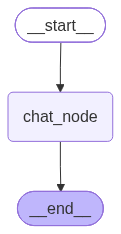

In [19]:
workflow

In [21]:
thread_id='1'
while True:
    user_message=input("Type here: ")

    print("USER: ",user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config={"configurable":{"thread_id":thread_id}}
    response=workflow.invoke({"messages":[HumanMessage(content=user_message)]},config=config)

    print("AI: ",response['messages'][-1].content)

USER:  hi i am mouryagna
AI:  Hello Mouryagna! How can I assist you today?
USER:  what is my name
AI:  Your name is Mouryagna.
USER:  sum of 100 n numbers
AI:  The sum of the first n natural numbers can be calculated using the formula: 
Sum = n*(n+1)/2

For n=100, the sum of the first 100 natural numbers would be:
Sum = 100*(100+1)/2
Sum = 100*101/2
Sum = 5050

So, the sum of the first 100 natural numbers is 5050.
USER:  how do you know all this
AI:  As a language model AI developed by OpenAI, I have been trained on a vast amount of data from various sources to provide accurate and helpful responses to a wide range of questions. My goal is to assist users with their inquiries to the best of my abilities. Let me know if you have any more questions!
USER:  bye



In [22]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi i am mouryagna', additional_kwargs={}, response_metadata={}, id='2577a94d-e21f-4032-9684-fcdea3dcaa3f'), AIMessage(content='Hello Mouryagna! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 13, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E7m1fSgYzG1BPBHpcRaaNZeOigubZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb961-a82f-7ba3-b4bd-8cd0b57a61c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 12, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detail